In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import hist

from models import carl, rolypoly
from physics.simulation import mcfm, msq
from physics.hzz import zz4l, zpair
from physics.hstar import c6

import torch
from torch.utils.data import TensorDataset, DataLoader
import lightning as L

In [2]:
JOB_DIR = '../jobs/'
SAMPLE_DIR = '../../data'

CARL_JOB = 'qqZZ-vs-SBI-05'
CARL_CKPT = [58,0.68]
ROLYPOLY_JOB = 'ggZZ-2.5M'
ROLYPOLY_CKPT = [[26,0.05],[87,0.16],[85,0.01],[50,0.03]]

SAMPLE_FILE_ggZZ = 'ggZZ2e2m_sbi.csv'
SAMPLE_FILE_qqZZ = 'qqZZ2e2m.csv'

CARL_PATH = os.path.join(JOB_DIR, 'carl', CARL_JOB)
CARL_CKPT_PATH = os.path.join(CARL_PATH, 'checkpoints', f'checkpoint-carl-epoch={CARL_CKPT[0]}-val_loss={CARL_CKPT[1]}.ckpt')
ROLYPOLY_PATH = os.path.join(JOB_DIR, 'rolypoly', ROLYPOLY_JOB)
ROLYPOLY_CKPT_PATHs = [os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}','checkpoints', f'checkpoint-rolypoly-epoch={ROLYPOLY_CKPT[i][0]}-val_loss={ROLYPOLY_CKPT[i][1]}.ckpt') for i in range(len(ROLYPOLY_CKPT))]
SAMPLE_PATH_ggZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_ggZZ)
SAMPLE_PATH_qqZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_qqZZ)

In [173]:
SAMPLE_SIZE = 2200000

luminosity = 3000

FEATURES = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

BATCH_SIZE = 512

C6_LINSPACE = [-20,20,361]
CH_LINSPACE = [-0.02,0.05,36]

C6_VAL_DATA = -10
CH_VAL_DATA = 0

SEED = 42

In [4]:
xs = {'ggZZ': 1.5569109*4, 'qqZZ': 14.482054*4}

In [5]:
events_ggZZ = mcfm.from_csv(cross_section=xs['ggZZ'], file_path=SAMPLE_PATH_ggZZ, n_rows=SAMPLE_SIZE*1.2)
events_qqZZ = mcfm.from_csv(cross_section=xs['qqZZ'], file_path=SAMPLE_PATH_qqZZ, n_rows=SAMPLE_SIZE*1.2)

zcandidates = zpair.ZPairCandidate(algorithm='leastsquare')
zmasses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
lepton_momenta = zz4l.LeptonMomenta()
fourlep = zz4l.FourLeptonSystem()
m4l_filter = zz4l.M4l(0,np.inf)

events_ggZZ_processed = events_ggZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta).calculate(fourlep).filter(m4l_filter)
events_qqZZ_processed = events_qqZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta).calculate(fourlep).filter(m4l_filter)

sigma_ggZZ = events_ggZZ_processed.weights.sum()
sigma_qqZZ = events_qqZZ_processed.weights.sum()

14.043811998701875
139.4764718062214


In [174]:
c6_mod = c6.Modifier(baseline=msq.Component.SBI, events=events_ggZZ_processed, c6_values=[-5,-1,0,1,5])
c6_weights, c6_prob = c6_mod.modify(c6=np.linspace(*C6_LINSPACE))#C6_VAL_DATA)

In [175]:
c6_index = np.where(np.linspace(*C6_LINSPACE)==C6_VAL_DATA)[0][0]
c6_zero_index = np.where(np.linspace(*C6_LINSPACE)==0.0)[0][0]

In [176]:
cH_index = np.where(np.round(np.linspace(*CH_LINSPACE),4)==CH_VAL_DATA)[0][0]
cH_zero_index = np.where(np.linspace(*CH_LINSPACE)==0.0)[0][0]

In [8]:
true_probs = np.array([np.concatenate([c6_weights[:SAMPLE_SIZE//2,i], events_qqZZ_processed[:SAMPLE_SIZE//2].weights]) for i in range(c6_weights.shape[1])])
true_probs /= np.sum(true_probs, axis=1)[:, np.newaxis]

In [177]:
# ggZZ + qqZZ

events_final = mcfm.Process(pd.concat([events_ggZZ_processed.kinematics[:SAMPLE_SIZE//2], events_qqZZ_processed.kinematics[:SAMPLE_SIZE//2]],ignore_index=True).reset_index(drop=True),
                            pd.concat([events_ggZZ_processed.components[:SAMPLE_SIZE//2], events_qqZZ_processed.components[:SAMPLE_SIZE//2]],ignore_index=True).reset_index(drop=True),
                            pd.concat([pd.Series((c6_weights[:,c6_index] - 2*CH_VAL_DATA*c6_weights[:,c6_zero_index]).flatten()).reset_index(drop=True)[:SAMPLE_SIZE//2]*np.sum((c6_weights[:,c6_index] - 2*CH_VAL_DATA*c6_weights[:,c6_zero_index]))/np.sum(c6_weights[:SAMPLE_SIZE//2, c6_index]  - 2*CH_VAL_DATA*c6_weights[:SAMPLE_SIZE//2,c6_zero_index]), events_qqZZ_processed.weights[:SAMPLE_SIZE//2].reset_index(drop=True)*sigma_qqZZ/events_qqZZ_processed.weights[:SAMPLE_SIZE//2].sum()],ignore_index=True).reset_index(drop=True))

In [10]:
# This is for ggZZ only

#events_final = mcfm.Process(events_ggZZ_processed.kinematics.reset_index(drop=True)[:SAMPLE_SIZE],
#                            events_ggZZ_processed.components.reset_index(drop=True)[:SAMPLE_SIZE],
#                            pd.Series(c6_weights[:,c6_index].flatten()).reset_index(drop=True)[:SAMPLE_SIZE]*np.sum(c6_weights[:,c6_index])/np.sum(c6_weights[:SAMPLE_SIZE,c6_index]))
                        #   Fixing the cross section to remain the same after cutting events to SAMPLE_SIZE

In [178]:
sigma_data = events_final.weights.sum()

In [12]:
kinematics = events_final.kinematics[FEATURES]

In [13]:
model_carl = carl.CARL.load_from_checkpoint(checkpoint_path=CARL_CKPT_PATH)

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:758: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [14]:
models_rolypoly = [rolypoly.ROLYPOLY.load_from_checkpoint(checkpoint_path=path) for path in ROLYPOLY_CKPT_PATHs]

In [15]:
with open(os.path.join(CARL_PATH, 'scaler.pkl'), 'rb') as f:
    scaler_carl = pickle.load(f)

X_carl = scaler_carl.transform(kinematics.to_numpy())
dl_carl = DataLoader(TensorDataset(torch.tensor(X_carl, dtype=torch.float32)), batch_size=BATCH_SIZE, num_workers=15)

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [16]:
trainer = L.Trainer(accelerator='cpu')

pred_carl = torch.concatenate(trainer.predict(model_carl, dl_carl)).numpy()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 4297/4297 [18:22<00:00,  3.90it/s]


In [17]:
r = pred_carl/(1-pred_carl)

In [18]:
# CARL calibration

ggZZ_wt_SM = events_ggZZ_processed[:SAMPLE_SIZE//2].weights.to_numpy() * sigma_ggZZ/events_ggZZ_processed[:SAMPLE_SIZE//2].weights.sum()

R = 1/sigma_ggZZ * np.sum(ggZZ_wt_SM * r[:SAMPLE_SIZE//2])

r /= R

In [19]:
dls_rolypoly = []
for i in range(len(ROLYPOLY_CKPT)):
    with open(os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}', 'scaler_X.pkl'), 'rb') as f:
        scaler_X = pickle.load(f)
    X_rolypoly = scaler_X.transform(kinematics.to_numpy())
    dl = DataLoader(TensorDataset(torch.tensor(X_rolypoly, dtype=torch.float32)), batch_size=BATCH_SIZE, num_workers=15)
    dls_rolypoly.append(dl)

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from vers

In [20]:
coeffs_pred = []

for i in range(len(ROLYPOLY_CKPT)):
    with open(os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}', 'scaler_y.pkl'), 'rb') as f:
        scaler_y = pickle.load(f)
    coeffs_pred.append(scaler_y.inverse_transform(torch.concatenate(trainer.predict(models_rolypoly[i], dls_rolypoly[i])).numpy()[:,np.newaxis]).flatten())

coeffs_pred = np.array(coeffs_pred).T

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Predicting DataLoader 0: 100%|██████████| 4297/4297 [10:29<00:00,  6.83it/s]


/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Predicting DataLoader 0: 100%|██████████| 4297/4297 [10:13<00:00,  7.01it/s]


/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Predicting DataLoader 0: 100%|██████████| 4297/4297 [09:27<00:00,  7.57it/s]


/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Predicting DataLoader 0: 100%|██████████| 4297/4297 [09:44<00:00,  7.35it/s]


In [21]:
coeffs_true = c6_mod.coefficients[:SAMPLE_SIZE,1:]

In [22]:
c6_values = np.linspace(*C6_LINSPACE)

In [23]:
def f(c6_values, coeffs):
    coefficients = np.concatenate([np.ones((len(coeffs),1)), coeffs], axis=1)
    c6_matrix = np.vander(c6_values, coefficients.shape[1], increasing=True).T
    return np.dot(coefficients, c6_matrix).T

In [150]:
sigma_ggZZ_BSM_c6 = np.sum(ggZZ_wt_SM[np.newaxis,:] * f(c6_values, coeffs_pred[:SAMPLE_SIZE//2]), axis=1) #c6 only
sigma_ggZZ_BSM = sigma_ggZZ_BSM_c6[:,np.newaxis] - 2 * np.linspace(*CH_LINSPACE)[np.newaxis,:] * sigma_ggZZ #c6 + cH
# This works because the order of events in events_ggZZ_processed and events_final is the same (for the first SAMPLE_SIZE//2 events)

In [151]:
# Comment out the sigma_qqZZ terms if performing on ggZZ only

full_SM_xs = sigma_ggZZ + sigma_qqZZ

full_BSM_xs = sigma_ggZZ_BSM + sigma_qqZZ 

nu_SM = full_SM_xs * luminosity
nu = full_BSM_xs * luminosity

In [179]:
N_data = sigma_data*luminosity

# Poisson term
t_1 = - 2 * N_data * (np.log(nu) - np.log(nu_SM)) + 2 * (nu - nu_SM) 

In [27]:
#p_ratio = full_SM_xs/full_BSM_xs[:,np.newaxis] * ((f(c6_values, coeffs_pred)[:,:,np.newaxis] - 2*np.linspace(*CH_LINSPACE)[np.newaxis,np.newaxis,:] + sigma_qqZZ/sigma_ggZZ*r[np.newaxis,:,np.newaxis])/(1 + sigma_qqZZ/sigma_ggZZ * r[np.newaxis,:,np.newaxis]))

In [28]:
#rescaling_factor = np.sum(p_ratio * true_probs[c6_zero_index,:][np.newaxis,:,np.newaxis], axis=1)

#p_ratio_fixed = p_ratio/rescaling_factor[:,np.newaxis]

In [180]:
# Used for ggZZ + qqZZ

batch_size = 10000

t_3 = np.zeros((C6_LINSPACE[2],CH_LINSPACE[2]))

rescaling_factor = np.zeros((C6_LINSPACE[2],CH_LINSPACE[2]))

for start_idx in range(0,SAMPLE_SIZE,batch_size):
    end_idx = min(start_idx + batch_size, SAMPLE_SIZE)
    if start_idx % 100*batch_size == 0:
        print(start_idx, end_idx)

    batch_weights = events_final.weights.to_numpy()[np.newaxis,start_idx:end_idx,np.newaxis]
    batch_pratio = full_SM_xs/full_BSM_xs[:,np.newaxis] * (f(c6_values, coeffs_pred[start_idx:end_idx])[:,:,np.newaxis] - 2*np.linspace(*CH_LINSPACE)[np.newaxis,np.newaxis,:] + sigma_qqZZ/sigma_ggZZ*r[np.newaxis,start_idx:end_idx,np.newaxis])/(1 + sigma_qqZZ/sigma_ggZZ * r[np.newaxis,start_idx:end_idx,np.newaxis])
    batch_log_term = np.log(batch_pratio)

    rescaling_factor += np.sum(batch_pratio * true_probs[c6_zero_index,:][np.newaxis,start_idx:end_idx,np.newaxis], axis=1)

    t_3 += -2*luminosity*np.sum(batch_weights*batch_log_term, axis=1)

t_3 += 2*luminosity*sigma_data*np.log(rescaling_factor)

#t_3 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:,np.newaxis] * np.log(p_ratio_fixed), axis=1)

0 10000


10000 20000
20000 30000
30000 40000
40000 50000
50000 60000
60000 70000
70000 80000
80000 90000
90000 100000
100000 110000
110000 120000
120000 130000
130000 140000
140000 150000
150000 160000
160000 170000
170000 180000
180000 190000
190000 200000
200000 210000
210000 220000
220000 230000
230000 240000
240000 250000
250000 260000
260000 270000
270000 280000
280000 290000
290000 300000
300000 310000
310000 320000
320000 330000
330000 340000
340000 350000
350000 360000
360000 370000
370000 380000
380000 390000
390000 400000
400000 410000
410000 420000
420000 430000
430000 440000
440000 450000
450000 460000
460000 470000
470000 480000
480000 490000
490000 500000
500000 510000
510000 520000
520000 530000
530000 540000
540000 550000
550000 560000
560000 570000
570000 580000
580000 590000
590000 600000
600000 610000
610000 620000
620000 630000
630000 640000
640000 650000
650000 660000
660000 670000
670000 680000
680000 690000
690000 700000
700000 710000
710000 720000
720000 730000
730000 74

In [30]:
# Used for ggZZ only

#batch_size = 10000

#t_2 = np.zeros((C6_LINSPACE[2],CH_LINSPACE[2]))

#for start_idx in range(0,SAMPLE_SIZE-200000,batch_size):
#    end_idx = min(start_idx + batch_size, SAMPLE_SIZE)
#    if start_idx % 100*batch_size == 0:
#        print(start_idx, end_idx)

#    batch_weights = events_final.weights.to_numpy()[np.newaxis,start_idx:end_idx,np.newaxis]
#    batch_log_term = np.log(sigma_ggZZ/sigma_ggZZ_BSM[:,np.newaxis] * (f(c6_values, coeffs_true[start_idx:end_idx])[:,:,np.newaxis] - 2*np.linspace(*CH_LINSPACE)[np.newaxis,np.newaxis,:]))

#    t_2 += -2*luminosity*np.sum(batch_weights*batch_log_term, axis=1)

In [181]:
t = t_1 + t_3

In [182]:
t[180]

array([ 8.53947776e-01,  4.77291547e-01,  1.65175148e-01, -8.23323205e-02,
       -2.65161616e-01, -3.83243352e-01, -4.36508000e-01, -4.24885885e-01,
       -3.48307188e-01, -2.06701944e-01, -4.35003866e-08,  2.71868770e-01,
        6.08974902e-01,  1.01138890e+00,  1.47918147e+00,  2.01242346e+00,
        2.61118586e+00,  3.27553982e+00,  4.00555665e+00,  4.80130778e+00,
        5.66286482e+00,  6.59029953e+00,  7.58368380e+00,  8.64308970e+00,
        9.76858943e+00,  1.09602554e+01,  1.22181600e+01,  1.35423761e+01,
        1.49329764e+01,  1.63900340e+01,  1.79136219e+01,  1.95038135e+01,
        2.11606822e+01,  2.28843017e+01,  2.46747458e+01,  2.65320884e+01])

In [183]:
c6_min_ind = np.nanargmin(t)//CH_LINSPACE[2]
cH_min_ind = np.nanargmin(t)%CH_LINSPACE[2]

t_min = t[c6_min_ind,cH_min_ind]

In [184]:
print(np.linspace(*C6_LINSPACE)[c6_min_ind], c6_min_ind)
print(np.linspace(*CH_LINSPACE)[cH_min_ind], cH_min_ind)

-10.222222222222223 88
0.0 10


In [158]:
c6_min_ind = 135
#cH_min_ind = 25

t_min = t[c6_min_ind,cH_min_ind]

In [185]:
t_min

-1.7830418682294535

In [186]:
X, Y = np.meshgrid(np.linspace(*C6_LINSPACE), np.linspace(*CH_LINSPACE))
Z = t.T

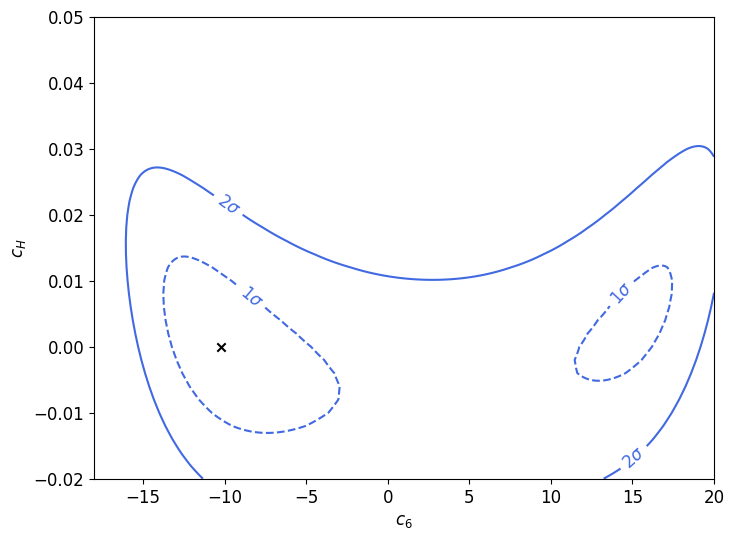

In [187]:
plt.figure(figsize=(8, 6))
contours = plt.contour(X, Y, Z, levels=[t_min+1,t_min+4], colors='royalblue', linestyles=['--','-'])
plt.clabel(contours, fmt=dict(zip([t_min+1,t_min+4], ['$1\sigma$', '$2\sigma$'])), fontsize=12)

plt.scatter(np.linspace(*C6_LINSPACE)[c6_min_ind], np.linspace(*CH_LINSPACE)[cH_min_ind], marker='x', color='k',label=f'minimum at $c_6={np.linspace(*C6_LINSPACE)[c6_min_ind]:0.2f}, c_H ={np.linspace(*CH_LINSPACE)[cH_min_ind]:0.4f}$')

#plt.legend(frameon=False)

plt.xlabel('$c_6$', fontsize=12)
plt.ylabel('$c_H$', fontsize=12)

plt.xlim(-18,20)
plt.ylim(-0.02,0.05)

plt.tick_params(axis='both', labelsize=12)

plt.show()

In [188]:
t_min = c6_values[np.nanargmin(t, axis=0)][cH_zero_index]

In [189]:
print(t_min)

-10.222222222222223


In [192]:
ci = np.sort(np.round(c6_values[np.argsort(np.abs(t-(np.min(t)+1)))[:2]], 2))
ci_2 = np.sort(np.round(c6_values[np.argsort(np.abs(t-(np.min(t)+4)))[:2]], 2))

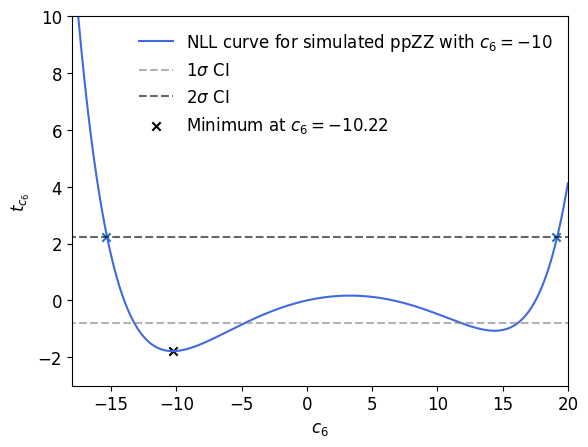

In [ ]:
plt.plot(c6_values, t[:,cH_zero_index], color='royalblue', label=f'NLL curve for simulated ppZZ with $c_6 = {C6_VAL_DATA}$')
plt.hlines(np.min(t[:,cH_zero_index])+1, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], linestyle='--', color='grey', alpha=0.6, label=f'$1\sigma$ CI')# [{ci[0]},{ci[1]}]')
plt.hlines(np.min(t[:,cH_zero_index])+4, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], linestyle='--', color='k', alpha=0.6, label=f'$2\sigma$ CI')# [{ci_2[0]},{ci_2[1]}]')
plt.scatter(t_min, np.min(t[:,cH_zero_index]), color='k', marker='x', label=f'Minimum at $c_6 = {round(t_min,2)}$')

#plt.scatter([-15.4, 19.1],[np.min(t[:,cH_zero_index])+4, np.min(t[:,cH_zero_index])+4],marker='x') #c6=-10
#plt.scatter([-13.2, 17.9],[np.min(t[:,25])+4, np.min(t[:,25])+4],marker='x') #c6=10

plt.xlabel('$c_6$', fontsize=12)
plt.ylabel('$t_{c_6}$', fontsize=12)
plt.ylim(-3,10)
plt.xlim(-18,20)
#plt.yscale('log')

plt.tick_params(axis='both', labelsize=12)

plt.legend(frameon=False, fontsize=12)
plt.show()